In [47]:
''' 
look at it by hour - can we infer when someone is actually using hot water; vs when it is idle
- subtract idle energy use from actual people use - integrating beneath the curve to get energy 

Is it possible to separate the pump from the thermostat? 
- fast fourier transform (turn it from a time domain to a frequency domain) 
- (thermostat is a high frequency device) vs heat
    - low frequency events due to a pump (pump)
'''

' \nlook at it by hour - can we infer when someone is actually using hot water; vs when it is idle\n- subtract idle energy use from actual people use - integrating beneath the curve to get energy \n\nIs it possible to separate the pump from the thermostat? \n- fast fourier transform (turn it from a time domain to a frequency domain) \n- (thermostat is a high frequency device) vs heat\n    - low frequency events due to a pump (pump)\n'

In [48]:
import numpy as np 
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# grab all daily files and combine
files = glob.glob("POWER_*.csv")

dfs = [pd.read_csv(f) for f in files]
wide = pd.concat(dfs, ignore_index=True)

In [50]:
DATE = "2026-07-14"

## 1. Data Cleaning

In [51]:
# pivot wide -> long
id_cols = ["entity_id", "type", "unit"]

long_parts = []
for f in files:
    df = pd.read_csv(f)
    melted = df.melt(id_vars=id_cols, var_name="timestamp", value_name="power_w")
    long_parts.append(melted)

long = pd.concat(long_parts, ignore_index=True)

n_before = len(long)
long = long.dropna(subset=["power_w"])
n_after = len(long)
print(f"Dropped {n_before - n_after} rows with missing power_w ({(n_before - n_after) / n_before * 100:.3f}%)")

long["power_w"] = pd.to_numeric(long["power_w"])
long["timestamp"] = pd.to_datetime(long["timestamp"], format="mixed", utc=True)

# clean duplicates
long = long.drop_duplicates(subset=["entity_id", "timestamp"])

# sort by time 
long = long.sort_values(by=['timestamp'])

long["diff_sec"] = (
    long.groupby("entity_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

Dropped 0 rows with missing power_w (0.000%)


In [52]:
print(f"First timestamp: {long['timestamp'].min()}")
print(f"Last timestamp:  {long['timestamp'].max()}")
print(f"Total span: {long['timestamp'].max() - long['timestamp'].min()}")

First timestamp: 2026-07-11 20:12:22.524808+00:00
Last timestamp:  2026-08-31 15:37:26.504349+00:00
Total span: 50 days 19:25:03.979541


In [53]:
long["diff_sec"].describe()

count    8.941300e+04
mean     4.909693e+01
std      5.449675e+03
min      2.656080e-01
25%      2.998655e+01
50%      3.000146e+01
75%      3.001680e+01
max      1.627969e+06
Name: diff_sec, dtype: float64

In [54]:
gap60 = long[long["diff_sec"].round(0) == 60]
print(f"Count: {len(gap60)}")
print(f"Total missed time: {gap60['diff_sec'].sum() / 60:.1f} minutes")
print(f"As % of window: {gap60['diff_sec'].sum() / (long['diff_sec'].sum()) * 100:.3f}%")

Count: 161
Total missed time: 161.0 minutes
As % of window: 0.220%


In [55]:
# imputation - for each row with diff_sec ~60 / 61 seconds, insert a row between the existing row before and itself, to make diff_sec ~30s
long = long.sort_values("timestamp").reset_index(drop=True)
long["diff_sec"] = long["timestamp"].diff().dt.total_seconds()

# find the gaps to fix
gap_mask = long["diff_sec"].between(59, 62)
gap_rows = long[gap_mask]

new_rows = []
for idx in gap_rows.index:
    before = long.loc[idx - 1]
    after = long.loc[idx]

    mid_timestamp = before["timestamp"] + (after["timestamp"] - before["timestamp"]) / 2
    mid_power = (before["power_w"] + after["power_w"]) / 2

    new_row = before.copy()
    new_row["timestamp"] = mid_timestamp
    new_row["power_w"] = mid_power
    new_rows.append(new_row)

# insert the new rows and re-sort
long = pd.concat([long, pd.DataFrame(new_rows)], ignore_index=True)
long = long.sort_values("timestamp").reset_index(drop=True)

# recompute diff_sec now that the gaps are filled
long["diff_sec"] = long["timestamp"].diff().dt.total_seconds()

In [56]:
print((long["diff_sec"].round(0) == 60).sum())  # should be 0 now
long["diff_sec"].describe()

0


count    8.957900e+04
mean     4.900595e+01
std      5.444623e+03
min      2.656080e-01
25%      2.998653e+01
50%      3.000143e+01
75%      3.001659e+01
max      1.627969e+06
Name: diff_sec, dtype: float64

In [57]:
big_gap = long[long["diff_sec"] > 60]
big_gap[["timestamp", "diff_sec"]]

# 2 outliers with diff_sec exceeding ~30 seconds

,timestamp,diff_sec
9255,2026-07-15 01:32:24.512480+00:00,7.699622e+02
29229,2026-07-22 20:12:10.505638+00:00,7.275499e+04
58484,2026-08-20 20:12:25.721938+00:00,1.627969e+06
73002,2026-08-25 21:19:34.567731+00:00,7.279723e+01
87369,2026-08-30 21:11:58.233755+00:00,7.662016e+01


In [58]:
long = long.sort_values("timestamp").reset_index(drop=True)
long["diff_sec"] = long["timestamp"].diff().dt.total_seconds()

# the two specific gaps you're after
target_gaps = long[long["diff_sec"].round(2).isin([769.96, 72754.99])]

for idx in target_gaps.index:
    before = long.loc[idx - 1, "timestamp"]
    after = long.loc[idx, "timestamp"]
    diff = long.loc[idx, "diff_sec"]
    print(f"Before: {before}  |  After: {after}  |  diff_sec: {diff:.3f}")

# There is a 20 hour gap; split at July 22. Sensor readings went down for a day. For this reason, must treat FFT independently on each segment.

Before: 2026-07-15 01:19:34.550249+00:00  |  After: 2026-07-15 01:32:24.512480+00:00  |  diff_sec: 769.962
Before: 2026-07-21 23:59:35.512519+00:00  |  After: 2026-07-22 20:12:10.505638+00:00  |  diff_sec: 72754.993


In [59]:
gap_threshold_sec = 60  # anything bigger than ~2x the expected 30s interval
long['segment_id'] = (long['diff_sec'] > gap_threshold_sec).cumsum()

long.groupby('segment_id').agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_samples=('timestamp', 'size')
)

,start,end,n_samples
segment_id,,,
0,2026-07-11 20:12:22.524808+00:00,2026-07-15 01:19:34.550249+00:00,9255
1,2026-07-15 01:32:24.512480+00:00,2026-07-21 23:59:35.512519+00:00,19974
2,2026-07-22 20:12:10.505638+00:00,2026-08-01 23:59:36.496174+00:00,29255
3,2026-08-20 20:12:25.721938+00:00,2026-08-25 21:18:21.770505+00:00,14518
4,2026-08-25 21:19:34.567731+00:00,2026-08-30 21:10:41.613592+00:00,14367
5,2026-08-30 21:11:58.233755+00:00,2026-08-31 15:37:26.504349+00:00,2211


In [60]:
long = long[['power_w', 'timestamp', 'diff_sec', 'segment_id']]
# what alias filter might i get? -> filter those out 
# aliasing 
# nyquist frequency

# long.describe()

In [61]:
long.head(10)

,power_w,timestamp,diff_sec,segment_id
0,2.750,2026-07-11 20:12:22.524808+00:00,NaN,0
1,2.667,2026-07-11 20:12:52.717167+00:00,30.192359,0
2,2.878,2026-07-11 20:13:22.538735+00:00,29.821568,0
3,2.975,2026-07-11 20:13:52.523467+00:00,29.984732,0
4,2.928,2026-07-11 20:14:22.651051+00:00,30.127584,0
5,2.987,2026-07-11 20:14:52.526337+00:00,29.875286,0
6,2.969,2026-07-11 20:15:22.533235+00:00,30.006898,0
7,3.257,2026-07-11 20:15:52.515931+00:00,29.982696,0
8,2.889,2026-07-11 20:16:22.516593+00:00,30.000662,0
9,3.003,2026-07-11 20:16:52.653037+00:00,30.136444,0


In [62]:
# non-intrusive load monitoring (NILM) + signal processing problem 

# disaggregating pump vs thermostat using FFT 
# thermostat (high-frequency)
# pump (low frequency; long, continuous stretch)

# assume 30 second gap + run fft 
# single-day 

## 2. FFT

Nyquist domain - sampling rate must be at least twice the highest frequency component of the signal to avoid aliasing (form of distortion caused by undersampling)

Converts time-domain into frequency-domain.
Which frequencies contribute the most energy to the signal?

In [63]:
from scipy.fft import fft, fftfreq 

Hypothesis: Water heater's total power draw is 2 devices: pump + thermostat. 
Fourier analysis attempts to separate these by looking at how often each component's signature repeats, rather than by looking at raw power level.

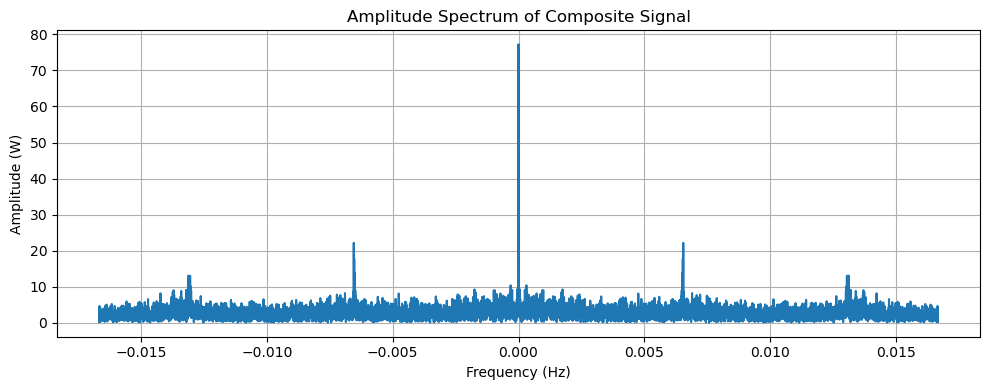

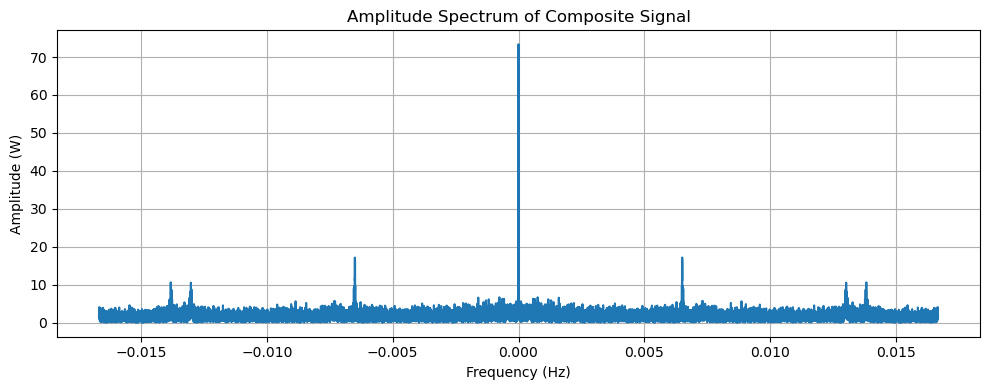

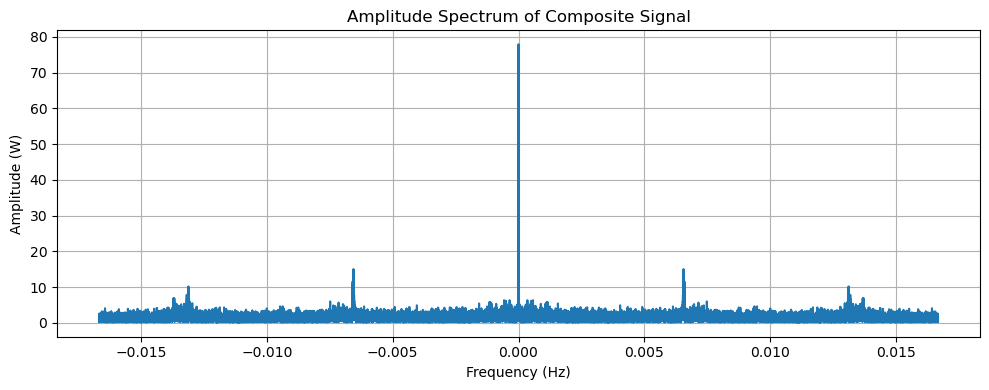

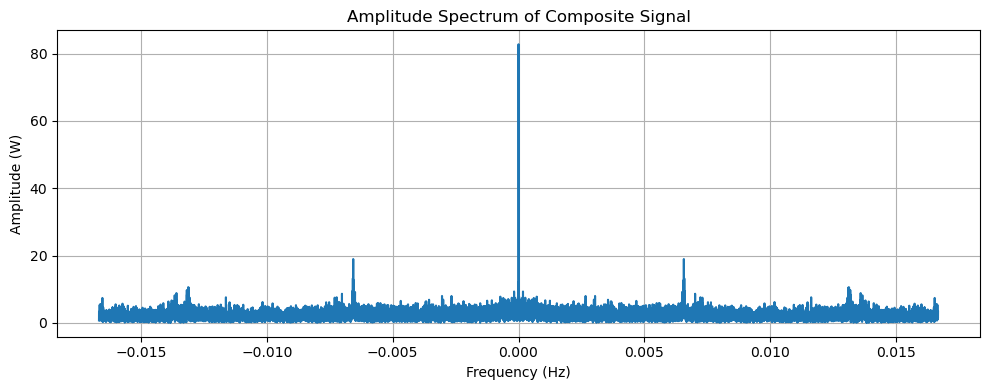

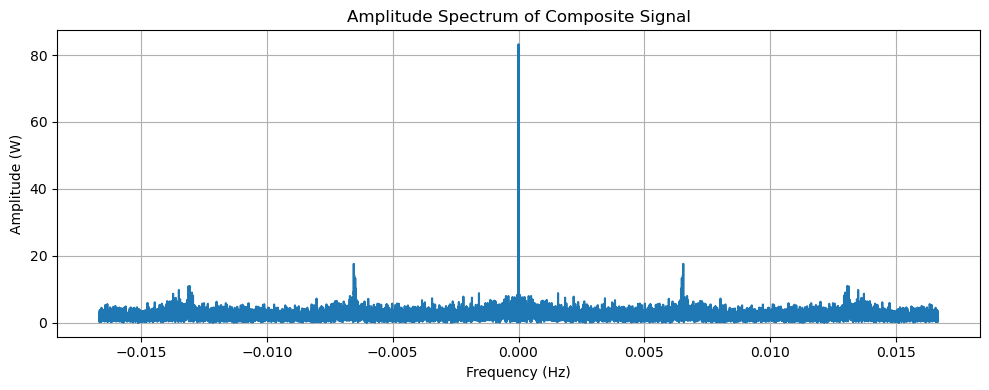

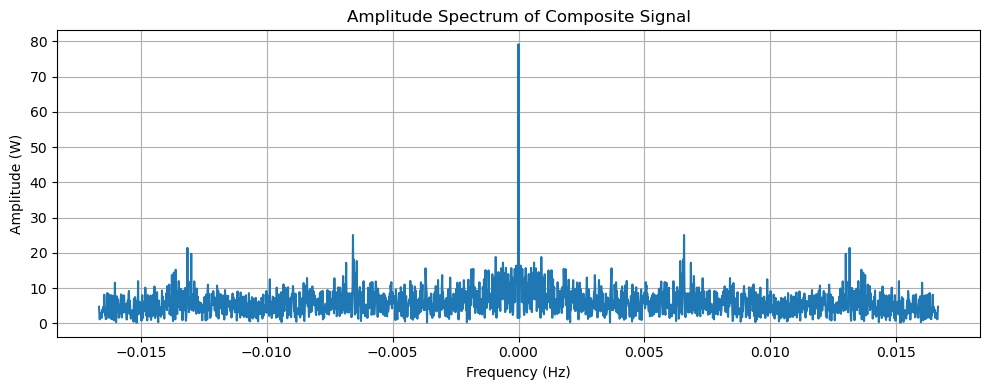

In [64]:
# fourier analysis: Any signal can be represented by a weighted sum of sine and cosine functions
# fourier transform decomposes signal into its frequency commponents 

# fil_long = long[long["timestamp"].dt.date == pd.Timestamp(DATE).date()] # Monday 

for seg_id, seg in long.groupby('segment_id'):
    seg = seg.dropna(subset=['power_w'])
    if len(seg) < 100:  # skip tiny leftover segments
        continue

    signal = seg["power_w"].to_numpy()
    fourier = fft(signal) # fft returns array of complex numbers that encode magnitudes and frequencies in signal

    frequencies = fftfreq(n=len(signal), d=30) # (n: signal length; no. of signals) (d: sample spacing)

    N = len(signal)
    power = np.abs(fourier) / N # freq=0 is mean(signal) = baseline for this time 
                                # Watts — amplitude of oscillation at each frequency

    freqs_shifted = np.fft.fftshift(frequencies)
    power_shifted = np.fft.fftshift(power)
    # plt.xlim(0, 0.45)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs_shifted, power_shifted)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (W)')
    plt.title('Amplitude Spectrum of Composite Signal')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [65]:
# Baseline usage (What is y-value at fq=0) for timeframe of 1 day (2026-07-13)? 59.04W for 24 hours. 

# Index where frequency is 0
zero_freq_idx = np.where(freqs_shifted == 0)[0][0]

# Extract the power at 0 Hz
power_at_zero = power_shifted[zero_freq_idx]

print(f"Power at 0 Hz: {power_at_zero:.2f} W for 24 hours.")

Power at 0 Hz: 79.18 W for 24 hours.


In [66]:
# Find dominant frequency peaks and convert to time intervals

from scipy.signal import find_peaks

# Use only positive frequencies (ignore negative frequencies from FFT symmetry)
positive_mask = frequencies > 0

positive_freqs = frequencies[positive_mask]
positive_mags = power[positive_mask]

# Find peaks in power spectrum
peaks, properties = find_peaks(positive_mags)

# Sort peaks by power (largest first)
top_peaks = peaks[np.argsort(positive_mags[peaks])[-10:]][::-1]

# Convert frequency peaks into intervals
for peak in top_peaks:
    f = positive_freqs[peak]
    amplitude = positive_mags[peak]
    
    period_seconds = 1 / f
    period_minutes = period_seconds / 60
    period_hours = period_minutes / 60
    
    print(
        f"Frequency: {f:.8f} Hz | "
        f"Power: {amplitude:.2f} | "
        f"Interval: {period_seconds:.1f} seconds "
        f"({period_minutes:.2f} minutes, {period_hours:.2f} hours)"
    )

Frequency: 0.00657319 Hz | Power: 25.07 | Interval: 152.1 seconds (2.54 minutes, 0.04 hours)
Frequency: 0.01314639 Hz | Power: 21.40 | Interval: 76.1 seconds (1.27 minutes, 0.02 hours)
Frequency: 0.01299563 Hz | Power: 19.74 | Interval: 76.9 seconds (1.28 minutes, 0.02 hours)
Frequency: 0.00090457 Hz | Power: 18.82 | Interval: 1105.5 seconds (18.43 minutes, 0.31 hours)
Frequency: 0.00654304 Hz | Power: 18.13 | Interval: 152.8 seconds (2.55 minutes, 0.04 hours)
Frequency: 0.00642243 Hz | Power: 17.69 | Interval: 155.7 seconds (2.60 minutes, 0.04 hours)
Frequency: 0.00061812 Hz | Power: 17.23 | Interval: 1617.8 seconds (26.96 minutes, 0.45 hours)
Frequency: 0.00684457 Hz | Power: 17.18 | Interval: 146.1 seconds (2.44 minutes, 0.04 hours)
Frequency: 0.00009046 Hz | Power: 16.38 | Interval: 11055.0 seconds (184.25 minutes, 3.07 hours)
Frequency: 0.00049751 Hz | Power: 15.75 | Interval: 2010.0 seconds (33.50 minutes, 0.56 hours)


In [67]:
# # weekday 
# weekday = long[
#     (long["timestamp"] >= "2026-07-13") &
#     (long["timestamp"] < "2026-07-18")
# ]

# weekday = weekday.dropna()
# weekday_signal = weekday["power_w"].to_numpy()
# weekday_fourier = fft(weekday_signal)
# weekday_freq = fftfreq(
#     n=len(weekday_signal),
#     d=30
# )

# weekday_power = np.abs(weekday_fourier) / len(weekday_signal)
# weekday_mask = weekday_freq > 0 # positive values only
# weekday_freq = weekday_freq[weekday_mask]
# weekday_power = weekday_power[weekday_mask]

# # weekend
# weekend = long[
#     (long["timestamp"] >= "2026-07-18") &
#     (long["timestamp"] < "2026-07-20")
# ]

# weekend = weekend.dropna()
# weekend_signal = weekend["power_w"].to_numpy()
# weekend_fourier = fft(weekend_signal)
# weekend_freq = fftfreq(
#     n=len(weekend_signal),
#     d=30
# )

# weekend_power = np.abs(weekend_fourier) / len(weekend_signal)
# weekend_mask = weekend_freq > 0
# weekend_freq = weekend_freq[weekend_mask]
# weekend_power = weekend_power[weekend_mask] 

In [68]:
# plt.figure(figsize=(10, 4))

# plt.plot(
#     weekday_freq,
#     weekday_power,
#     label="Weekday (Mon-Fri)"
# )

# plt.plot(
#     weekend_freq,
#     weekend_power,
#     label="Weekend (Sat-Sun)"
# )

# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Power (W)")
# plt.title("FFT Spectrum: Weekday vs Weekend Power Consumption")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

## 3. Statistics

#### Gaussian Mixture Model

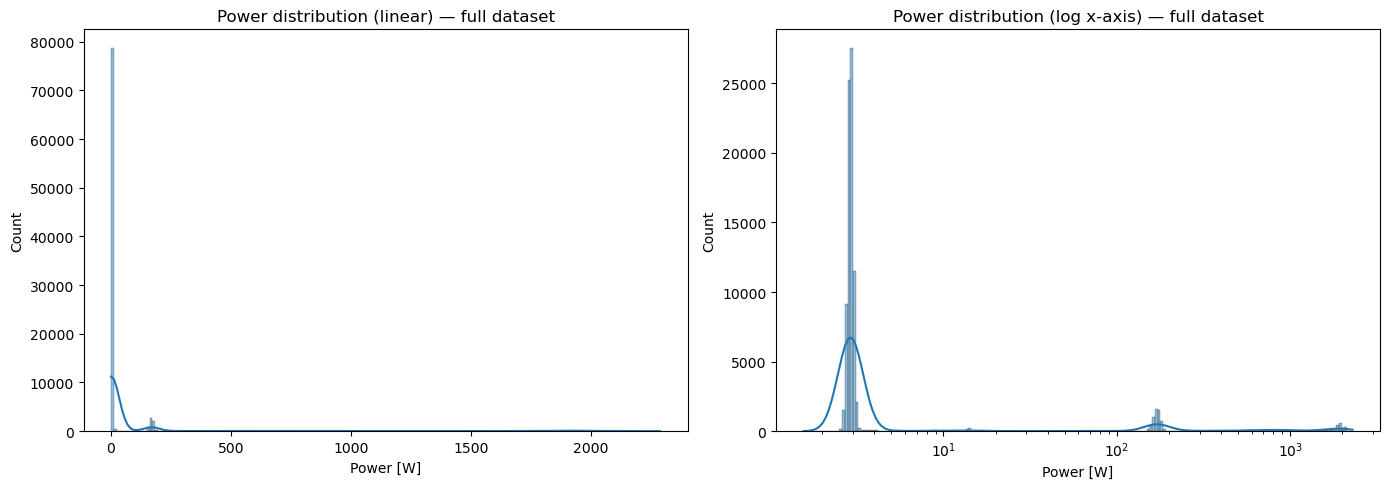

In [69]:
# fil_long = long[long["timestamp"].dt.date == pd.Timestamp(DATE).date()]

power = long['power_w'].dropna()
power_nonzero = power[power > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(power_nonzero, bins=200, kde=True, ax=axes[0])
axes[0].set_title('Power distribution (linear) — full dataset')
axes[0].set_xlabel('Power [W]')

sns.histplot(power_nonzero, bins=200, kde=True, ax=axes[1], log_scale=True)
axes[1].set_title('Power distribution (log x-axis) — full dataset')
axes[1].set_xlabel('Power [W]')

plt.tight_layout()
plt.show()

# filter out baseline energy usage from human usage - then fit 
# Was there a power threshold for more than 40 seconds - Yes/No; sliding window 

In [70]:
from sklearn.mixture import GaussianMixture

# Gaussian Mixtude model - why? 
# assume data comes from 3 underlying Gaussian ("mode") clusters 
train_data = long.loc[long['power_w'] > 0, 'power_w'].values.reshape(-1, 1)
gmm3 = GaussianMixture(n_components=3, random_state=42, n_init=10) # run EM alogirhtm 10 times, different initialisations, keeps best fit
gmm3.fit(train_data)

print("Means:", sorted(gmm3.means_.flatten()))

# 2.9W - 'everything off'
# 250.8W - 'pump running alone' = cold water 
# 1839.8W - 'heating element active'

Means: [2.91151105938291, 250.26537491469276, 1852.614687128083]


### Step 1. Establish the event threshold

In [71]:
# if power > 260 W for more than 25 seconds = Human use 

spike_threshold_w  = 260
min_duration_sec = 25

#### Step 2. Detect and log every human event

In [72]:
# long = long[long['timestamp'].dt.date == pd.Timestamp(DATE).date()]

In [73]:
long = long.sort_values('timestamp').reset_index(drop=True)
long['diff_sec'] = long['timestamp'].diff().dt.total_seconds()

# flag each instance as above/below power threshold 
above = long['power_w'] > spike_threshold_w

# continuous run of above/below samples given a unique id 
# (id only changes when above/below state flips, so one run = one id)
long['block_id'] = (above != above.shift()).cumsum()

# for every continuous run that's above threshold, how long does it last? 
event_blocks = (
    long[above]
    .groupby('block_id')['timestamp']
    .agg(start='min', end='max')
)
event_blocks['duration_sec'] = (event_blocks['end'] - event_blocks['start']).dt.total_seconds()

# only keep runs that stay above threshold for more than min_duration_sec
qualifying_blocks = event_blocks[event_blocks['duration_sec'] > min_duration_sec]
qualifying_blocks['date'] = qualifying_blocks['start'].dt.tz_convert('Australia/Perth').dt.date

# mark event_start only at the first sample of each qualifying (real, human-length)
long['event_start'] = long['block_id'].map(qualifying_blocks['start'])
long.loc[long['timestamp'] != long['event_start'], 'event_start'] = pd.NaT


/var/folders/2g/msdc86l95_sfy8q7n1j1jmqc0000gn/T/ipykernel_29485/960309178.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  qualifying_blocks['date'] = qualifying_blocks['start'].dt.tz_convert('Australia/Perth').dt.date


In [74]:
# Round to nearest whole second and count frequencies
duration_counts = event_blocks['duration_sec'].round().value_counts().sort_index()
print(duration_counts)

duration_sec
0.0      3916
29.0        1
30.0      122
31.0        4
60.0       28
61.0        1
62.0        1
90.0       15
91.0        3
120.0       3
121.0       1
150.0       1
180.0       3
Name: count, dtype: int64


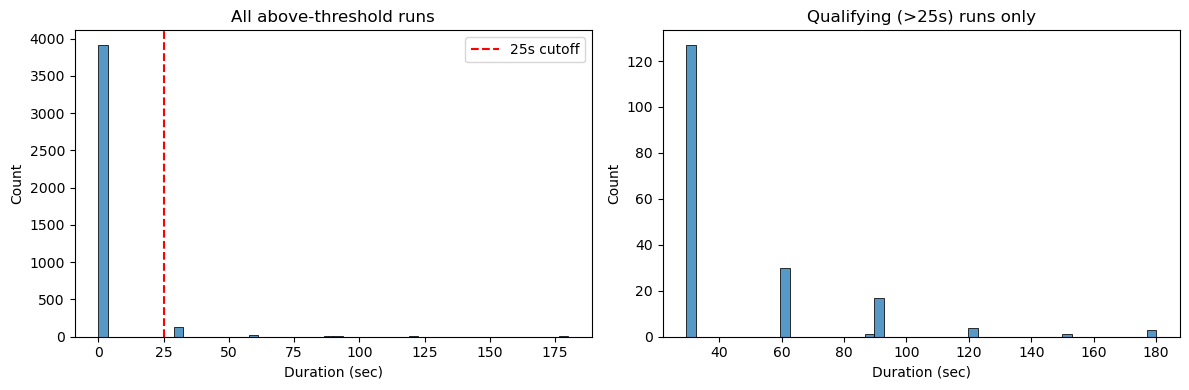

In [75]:
# spread of runs?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(event_blocks['duration_sec'], bins=50, ax=axes[0])
axes[0].axvline(min_duration_sec, color='red', linestyle='--', label=f'{min_duration_sec}s cutoff')
axes[0].set_title('All above-threshold runs')
axes[0].set_xlabel('Duration (sec)')
axes[0].legend()

sns.histplot(qualifying_blocks['duration_sec'], bins=50, ax=axes[1])
axes[1].set_title('Qualifying (>25s) runs only')
axes[1].set_xlabel('Duration (sec)')

plt.tight_layout()
plt.show()

# my explanation of these 'robotic intervals' 
# Data was gathered using a Tapo smart energy monitoring plug that records power readings at fixed 30-second intervals
# Because the plug polls at fixed time points rather than logging continuously, events are measured in discrete 30-second blocks
# Minor variations in event duration (like 29, 31, 61 are due to small network transmission delays and API polling jitter.

# Measured duration acts as a "bounding window" rather than the exact duration the water tap was open.
# If a person uses the tap for 10–20 seconds inside a single 30-second window, the system records 1 sample above the power threshold, resulting in a recorded duration of 30 seconds
# If a 35-second tap run crosses the boundary between two polling windows, both windows register high power, causing the system to record a 60 second duration.

In [76]:
# investigating these 'qualifying runs'

qualifying_blocks = qualifying_blocks.copy()

# pull power stats per block from long
power_stats = (
    long[long['power_w'] > spike_threshold_w]
    .groupby('block_id')['power_w']
    .agg(peak_power_w='max', mean_power_w='mean')
)
qualifying_blocks = qualifying_blocks.join(power_stats)

# convert to Perth local time first
qualifying_blocks['start_perth'] = qualifying_blocks['start'].dt.tz_convert('Australia/Perth')
qualifying_blocks['end_perth'] = qualifying_blocks['end'].dt.tz_convert('Australia/Perth')

# now format the Perth-local versions
qualifying_blocks['start_time_of_day'] = qualifying_blocks['start_perth'].dt.strftime('%I:%M:%S %p')
qualifying_blocks['end_time_of_day'] = qualifying_blocks['end_perth'].dt.strftime('%I:%M:%S %p')

qualifying_blocks['duration_bucket'] = pd.cut(
    qualifying_blocks['duration_sec'],
    bins=[0, 45, 75, 105, 135, 165, 195, float('inf')],
    labels=['~30s', '~60s', '~90s', '~120s', '~150s', '~180s', '>180s'],
)

qualifying_blocks_sorted = qualifying_blocks.sort_values('start')[
    ['start', 'start_perth', 'start_time_of_day', 'duration_sec', 'duration_bucket',
     'peak_power_w']
]
qualifying_blocks_sorted

,start,start_perth,start_time_of_day,duration_sec,duration_bucket,peak_power_w
block_id,,,,,,
280,2026-07-13 00:18:58.527305+00:00,2026-07-13 08:18:58.527305+08:00,08:18:58 AM,89.991739,~90s,2095.499
282,2026-07-13 00:21:28.517598+00:00,2026-07-13 08:21:28.517598+08:00,08:21:28 AM,30.003606,~30s,1059.299
284,2026-07-13 00:27:28.521864+00:00,2026-07-13 08:27:28.521864+08:00,08:27:28 AM,30.006502,~30s,1939.272
292,2026-07-13 01:14:59.522812+00:00,2026-07-13 09:14:59.522812+08:00,09:14:59 AM,90.989202,~90s,2112.045
302,2026-07-13 02:24:32.525742+00:00,2026-07-13 10:24:32.525742+08:00,10:24:32 AM,29.994034,~30s,2090.066
...,...,...,...,...,...,...
8106,2026-08-31 05:04:54.772921+00:00,2026-08-31 13:04:54.772921+08:00,01:04:54 PM,59.995457,~60s,2056.299
8110,2026-08-31 05:22:55.762487+00:00,2026-08-31 13:22:55.762487+08:00,01:22:55 PM,29.918175,~30s,2063.608
8116,2026-08-31 05:58:30.743480+00:00,2026-08-31 13:58:30.743480+08:00,01:58:30 PM,59.933757,~60s,2089.898


### Occupancy

In [77]:
occupancy = pd.read_csv("OccupancyLog_0711_0801.csv")

In [78]:
occupancy['timestamp_start'] = pd.to_datetime(occupancy['timestamp_start'], utc=True)
occupancy['timestamp_end'] = pd.to_datetime(occupancy['timestamp_end'], utc=True)

occupancy_long = occupancy[
    occupancy['timestamp_start'].dt.tz_convert('Australia/Perth').dt.date == pd.Timestamp(DATE).date()
]

In [79]:
occupancy_long.head(10)

,timestamp_start,timestamp_end,entrances,avg_occupancy,temp_c,humidity_pct
108,2026-07-13 19:19:12.035000+00:00,2026-07-13 19:20:12.035000+00:00,1,0.003,23.0,59
109,2026-07-13 19:20:12.200000+00:00,2026-07-13 19:21:12.200000+00:00,2,0.086,23.0,59
110,2026-07-13 19:21:12.364000+00:00,2026-07-13 19:22:12.364000+00:00,1,0.013,23.0,59
111,2026-07-13 19:27:13.151000+00:00,2026-07-13 19:28:13.151000+00:00,0,0.003,23.0,59
112,2026-07-14 00:21:50.984000+00:00,2026-07-14 00:22:50.984000+00:00,0,0.007,23.0,59
113,2026-07-14 00:24:51.378000+00:00,2026-07-14 00:25:51.378000+00:00,0,0.007,23.0,59
114,2026-07-14 00:32:52.394000+00:00,2026-07-14 00:33:52.394000+00:00,1,0.007,23.0,59
115,2026-07-14 00:43:53.802000+00:00,2026-07-14 00:44:53.802000+00:00,0,0.003,23.0,59
116,2026-07-14 01:10:57.342000+00:00,2026-07-14 01:11:57.342000+00:00,2,0.633,23.0,59
117,2026-07-14 01:11:57.407000+00:00,2026-07-14 01:12:57.407000+00:00,4,0.086,23.0,59


In [80]:
# parse occupancy timestamps (they're UTC per the Z suffix)
occupancy['timestamp_start'] = pd.to_datetime(occupancy['timestamp_start'], utc=True)
occupancy['timestamp_end'] = pd.to_datetime(occupancy['timestamp_end'], utc=True)
occupancy = occupancy.drop_duplicates(subset=['timestamp_start', 'timestamp_end']).reset_index(drop=True)

# filter to the day you're investigating (Perth-local date)
# occupancy_long = occupancy[
#     occupancy['timestamp_start'].dt.tz_convert('Australia/Perth').dt.date == pd.Timestamp(DATE).date()
# ]

# match each qualifying block to overlapping occupancy windows
def get_occupancy_for_block(row, occupancy_df):
    overlap = occupancy_df[
        (occupancy_df['timestamp_start'] < row['end']) &
        (occupancy_df['timestamp_end'] > row['start'])
    ]
    return pd.Series({
        'occ_entrances': overlap['entrances'].sum(),
        'occ_avg_occupancy': overlap['avg_occupancy'].mean(),
        'occ_windows_matched': len(overlap)
    })

occ_match = qualifying_blocks.apply(get_occupancy_for_block, axis=1, occupancy_df=occupancy_long)
qualifying_blocks = qualifying_blocks.join(occ_match)

# rebuild the display table with occupancy columns included
qualifying_blocks_sorted = qualifying_blocks.sort_values('start')[
    ['start', 'start_perth', 'start_time_of_day', 'duration_sec', 'duration_bucket',
     'peak_power_w', 'occ_entrances', 'occ_avg_occupancy', 'occ_windows_matched']
]
qualifying_blocks_sorted

# limitation - There is no real way for me to confirm that occupancy sensor confirms that a person is using tap, as there are 2 entrances to ICP, and the Meraki sensor is only on one. 
# I can however deduce that at positive evidence (an entrance/occupancy reading confirms someone was there via that door), not negative evidence (a missing or zero reading does not mean the room was empty).

,start,start_perth,start_time_of_day,duration_sec,duration_bucket,peak_power_w,occ_entrances,occ_avg_occupancy,occ_windows_matched
block_id,,,,,,,,,
280,2026-07-13 00:18:58.527305+00:00,2026-07-13 08:18:58.527305+08:00,08:18:58 AM,89.991739,~90s,2095.499,0.0,NaN,0.0
282,2026-07-13 00:21:28.517598+00:00,2026-07-13 08:21:28.517598+08:00,08:21:28 AM,30.003606,~30s,1059.299,0.0,NaN,0.0
284,2026-07-13 00:27:28.521864+00:00,2026-07-13 08:27:28.521864+08:00,08:27:28 AM,30.006502,~30s,1939.272,0.0,NaN,0.0
292,2026-07-13 01:14:59.522812+00:00,2026-07-13 09:14:59.522812+08:00,09:14:59 AM,90.989202,~90s,2112.045,0.0,NaN,0.0
302,2026-07-13 02:24:32.525742+00:00,2026-07-13 10:24:32.525742+08:00,10:24:32 AM,29.994034,~30s,2090.066,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...
8106,2026-08-31 05:04:54.772921+00:00,2026-08-31 13:04:54.772921+08:00,01:04:54 PM,59.995457,~60s,2056.299,0.0,NaN,0.0
8110,2026-08-31 05:22:55.762487+00:00,2026-08-31 13:22:55.762487+08:00,01:22:55 PM,29.918175,~30s,2063.608,0.0,NaN,0.0
8116,2026-08-31 05:58:30.743480+00:00,2026-08-31 13:58:30.743480+08:00,01:58:30 PM,59.933757,~60s,2089.898,0.0,NaN,0.0


In [81]:
# investigate the high numbers (60s, 90s, 120s, 150s, 180s)

# Filter directly on numerical duration (>= 90s seconds)
long_events_df = qualifying_blocks_sorted[
    qualifying_blocks_sorted['duration_sec'] >= 88
]

long_events_df

,start,start_perth,start_time_of_day,duration_sec,duration_bucket,peak_power_w,occ_entrances,occ_avg_occupancy,occ_windows_matched
block_id,,,,,,,,,
280,2026-07-13 00:18:58.527305+00:00,2026-07-13 08:18:58.527305+08:00,08:18:58 AM,89.991739,~90s,2095.499,0.0,NaN,0.0
292,2026-07-13 01:14:59.522812+00:00,2026-07-13 09:14:59.522812+08:00,09:14:59 AM,90.989202,~90s,2112.045,0.0,NaN,0.0
544,2026-07-14 00:24:36.511669+00:00,2026-07-14 08:24:36.511669+08:00,08:24:36 AM,90.009237,~90s,2123.217,0.0,0.007,2.0
906,2026-07-15 05:37:33.545011+00:00,2026-07-15 13:37:33.545011+08:00,01:37:33 PM,90.606202,~90s,2276.189,0.0,NaN,0.0
1108,2026-07-16 01:25:58.510724+00:00,2026-07-16 09:25:58.510724+08:00,09:25:58 AM,119.992949,~120s,2109.345,0.0,NaN,0.0
1350,2026-07-17 01:04:24.501615+00:00,2026-07-17 09:04:24.501615+08:00,09:04:24 AM,90.012837,~90s,1960.274,0.0,NaN,0.0
2344,2026-07-21 00:57:22.541900+00:00,2026-07-21 08:57:22.541900+08:00,08:57:22 AM,89.989477,~90s,2116.097,0.0,NaN,0.0
2346,2026-07-21 00:59:52.609148+00:00,2026-07-21 08:59:52.609148+08:00,08:59:52 AM,119.922007,~120s,2094.296,0.0,NaN,0.0
2380,2026-07-21 03:09:58.504746+00:00,2026-07-21 11:09:58.504746+08:00,11:09:58 AM,90.013609,~90s,2105.021,0.0,NaN,0.0


In [82]:
standby_w = sorted(gmm3.means_.flatten())[0]          # idle mode from GMM

long['excess_w'] = (long['power_w'] - standby_w).clip(lower=0)   # power above baseline
long['excess_wh'] = long['excess_w'] * long['diff_sec'] / 3600   # power × time = energy (Wh)

qualifying_mask = long['block_id'].isin(qualifying_blocks.index)
event_energy = long[qualifying_mask].groupby('block_id')['excess_wh'].sum()
qualifying_blocks = qualifying_blocks.join(event_energy.rename('human_use_wh'))

total_wh = (long['power_w'] * long['diff_sec'] / 3600).sum()
human_use_wh = long.loc[qualifying_mask, 'excess_wh'].sum()
baseline_wh = total_wh - human_use_wh

### Step 3. Bin events by time interval

On average, how many events happen in each hours of the day, splift by weekday vs weekends.

In [83]:
# Uses `events` (from your event_start detection step) and `long` (for the full date range)
events = long.dropna(subset=['event_start']).copy()
events['event_start'] = pd.to_datetime(events['event_start'])
events['event_start_local'] = events['event_start'].dt.tz_convert('Australia/Perth')
events['hour'] = events['event_start_local'].dt.hour
events['date'] = events['event_start_local'].dt.date

# Count events per hour per day
counts_per_day = (
    events.groupby(['date', 'hour'])
    .size()
    .rename('event_count')
    .reset_index()
)

long_local = long.copy()
long_local['timestamp_local'] = long_local['timestamp'].dt.tz_convert('Australia/Perth')
long_local['date'] = long_local['timestamp_local'].dt.date
long_local['hour'] = long_local['timestamp_local'].dt.hour

# every (date, hour) pair where there is at least one raw sensor reading
observed_date_hours = (
    long_local[['date', 'hour']]
    .drop_duplicates()
)

# is_weekend is a property of the date, not of individual events 
observed_date_hours['is_weekend'] = pd.to_datetime(observed_date_hours['date']).dt.dayofweek >= 5

# Left-join event counts onto the full observed grid.
# Any (date, hour) that had sensor data but no event now explicitly gets 0 instead of being absent from the average entirely.
full_counts = observed_date_hours.merge(
    counts_per_day, on=['date', 'hour'], how='left'
)
full_counts['event_count'] = full_counts['event_count'].fillna(0)

# now, mean is a true "expected events per hour across all observed days",
# because quiet hours contribute a 0 instead of being skipped.
avg_per_hour = (
    full_counts.groupby(['hour', 'is_weekend'])['event_count']
    .mean()
    .reset_index()
)

# Still need this in case some (hour, is_weekend) combo never appeared at all in the observed data 
# (e.g. if dataset has zero weekend days with sensor coverage at some particular hour) — same as before.
full_index = pd.MultiIndex.from_product([range(24), [False, True]], names=['hour', 'is_weekend'])
avg_per_hour = (
    avg_per_hour.set_index(['hour', 'is_weekend'])
    .reindex(full_index, fill_value=0)
    .rename(columns={'event_count': 'avg_events_per_hour'})
    .reset_index()
)

avg_per_hour

,hour,is_weekend,avg_events_per_hour
0,0,False,0.050000
1,0,True,0.000000
2,1,False,0.000000
3,1,True,0.100000
4,2,False,0.000000
5,2,True,0.000000
6,3,False,0.000000
7,3,True,0.000000
8,4,False,0.045455
9,4,True,0.000000


### Step 4. Convert counts into ticking probabilities.

In [84]:
# lambda = average events per hour / 60 minutes
avg_per_hour['lambda_per_min'] = avg_per_hour['avg_events_per_hour'] / 60

# P(at least 1 event in this minute) = 1 - e^(-lambda)
avg_per_hour['p_trigger'] = 1 - np.exp(-avg_per_hour['lambda_per_min'])

# Build two 24-length lookup arrays: one for weekdays, one for weekends
p_weekday = (
    avg_per_hour[avg_per_hour['is_weekend'] == False]
    .set_index('hour')['p_trigger']
    .reindex(range(24), fill_value=0)
    .values
)
p_weekend = (
    avg_per_hour[avg_per_hour['is_weekend'] == True]
    .set_index('hour')['p_trigger']
    .reindex(range(24), fill_value=0)
    .values
)

print(f"\nWeekday probabilities: \n{p_weekday}")
print(f"\nWeekend probabilities: \n{p_weekend}")

# Most weekday early-morning and late-evening hours (1-6am, 6pm-10pm, and almost entire weekend array show 0)


Weekday probabilities: 
[0.00083299 0.         0.         0.         0.00075729 0.
 0.         0.00528899 0.02662331 0.02197713 0.01340145 0.01340145
 0.01183418 0.01340145 0.01730877 0.00711741 0.00396039 0.00158604
 0.         0.         0.         0.         0.         0.00158604]

Weekend probabilities: 
[0.         0.00166528 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00166528 0.00166528 0.         0.00166528 0.
 0.         0.         0.00166528 0.00166528 0.         0.        ]


### Step 5. Implement ABM logic

In [85]:
import random

def water_heater_tick(simulation_time, p_weekday, p_weekend, water_heater):
    """
    Call this once per simulated minute.
    """
    is_weekend = simulation_time.weekday() >= 5
    lookup = p_weekend if is_weekend else p_weekday

    current_hour = simulation_time.hour
    p_trigger = lookup[current_hour]

    if random.random() < p_trigger:
        # A human agent "uses" the water heater this minute
        water_heater.activate_human_use_state()
    else:
        # No human interaction — standard standby rules apply
        water_heater.run_standby_tick()


# Example usage inside your ABM's main loop:
# for simulation_time in simulation_timeline:  # stepping minute by minute
#     water_heater_tick(simulation_time, p_weekday, p_weekend, water_heater)